In [47]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

In [31]:
# load data as a frame
df = load_breast_cancer(as_frame = True).frame

In [32]:
df.shape

(569, 31)

In [33]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [34]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [35]:
X = df.drop(columns = ['target'])
y = df['target']

In [36]:
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [37]:
standard_scaler = StandardScaler()

# to avoid data leakage
x_train_scaled = standard_scaler.fit_transform(x_train)
x_test_scaled = standard_scaler.transform(x_test)

In [38]:
model = Sequential([
    # Dense : neurons, activation function, input shape
    # neurons is the number of nodes in the layer
    # activation function is the function that is applied to the output of the layer
    # types : relu, sigmoid, softmax, tanh, step, linear, etc
    
    
    # input layer
    # input shape is the number of features in the dataset
    # 30 cause there are 30 features in the dataset 
    Dense(32 , activation = 'relu' , input_shape = (30,)),
    
    
    # hidden layers
    Dense(16, activation = 'relu'),
    
    
    # output layer
    # sigmoid cause we have binary classification problem
    Dense(1, activation = 'sigmoid')
])

model.summary()

c:\Users\RED  LINE\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# optimizer is the algorithm that is used to update the weights of the model during training
    # can be SGD, Adam, RMSprop, etc
    # optimizer = "Adam" or "sgd" or "rmsprop" or "adagrad" or "adadelta" or "adamax" or "nadam" or "ftrl"
    # Adam(learning_rate = 0.001) is the default learning rate for Adam optimizer
# loss is the function that is used to calculate the error of the model during training
    # binary_crossentropy is used for binary classification problems
# metrics is the list of metrics that are used to evaluate the performance of the model during training and testing
    # accuracy is the default metric for classification problems

model.compile(optimizer = Adam(learning_rate = 0.001) , loss = 'binary_crossentropy' , metrics = ['accuracy'])


# epoch is the number of times the model will be trained on the entire dataset
# validation_split is the percentage of the training data that will be used for validation
# batch_size is the number of samples that will be used in each iteration of training
# verbose is the level of verbosity of the training process
    # 0 = silent, 1 = progress bar, 2 = one line per epoch
# this code without callbacks 
# callbacks are functions that are called during training and can be used to monitor the training process and make changes to the model or training process

history_model = model.fit(x_train_scaled , y_train , epochs = 30 , batch_size = 32 , validation_split = 0.2, verbose = 2)

Epoch 1/30
12/12 - 1s - 120ms/step - accuracy: 0.4973 - loss: 0.7314 - val_accuracy: 0.7473 - val_loss: 0.5876
Epoch 2/30
12/12 - 0s - 9ms/step - accuracy: 0.8297 - loss: 0.5158 - val_accuracy: 0.8901 - val_loss: 0.4376
Epoch 3/30
12/12 - 0s - 9ms/step - accuracy: 0.9231 - loss: 0.3920 - val_accuracy: 0.9121 - val_loss: 0.3389
Epoch 4/30
12/12 - 0s - 10ms/step - accuracy: 0.9533 - loss: 0.3058 - val_accuracy: 0.9451 - val_loss: 0.2697
Epoch 5/30
12/12 - 0s - 8ms/step - accuracy: 0.9588 - loss: 0.2417 - val_accuracy: 0.9451 - val_loss: 0.2224
Epoch 6/30
12/12 - 0s - 8ms/step - accuracy: 0.9615 - loss: 0.1963 - val_accuracy: 0.9560 - val_loss: 0.1899
Epoch 7/30
12/12 - 0s - 8ms/step - accuracy: 0.9670 - loss: 0.1630 - val_accuracy: 0.9670 - val_loss: 0.1666
Epoch 8/30
12/12 - 0s - 8ms/step - accuracy: 0.9725 - loss: 0.1400 - val_accuracy: 0.9670 - val_loss: 0.1496
Epoch 9/30
12/12 - 0s - 8ms/step - accuracy: 0.9753 - loss: 0.1229 - val_accuracy: 0.9670 - val_loss: 0.1370
Epoch 10/30
12/1

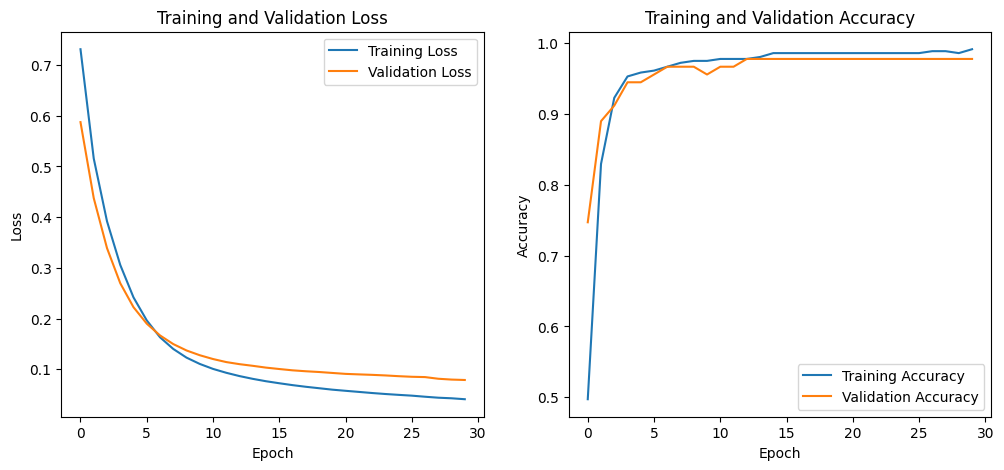

In [45]:
loss = history_model.history['loss']
loss_val = history_model.history['val_loss']
accuracy = history_model.history['accuracy']
accuracy_val = history_model.history['val_accuracy']


# want to make subplots for loss and accuracy
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(x_test_scaled)

# argmax is used to get the index of the maximum value in the array, which is the predicted class
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0])

In [ ]:
# is there a solution for all predictions to be 0? 
# Yes, it is possible that all predictions are 0 if the model is not trained well or if the data is imbalanced. 
# In this case, we can try to balance the data by oversampling the minority class or undersampling the majority class.
# We can also try to change the architecture of the model or use a different optimizer or learning rate.

# ravel is used to flatten the array, so that it can be compared with the true labels
y_pred2 = (model.predict(x_test_scaled) > 0.5).astype("int32").ravel()
y_pred2

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 0], dtype=int32)

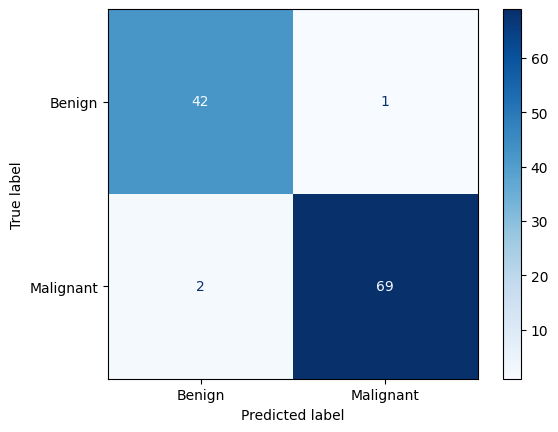

In [53]:
# ['Benign', 'Malignant'] is the order of the classes in the target variable, where 0 is Benign and 1 is Malignant. Therefore, we can use this order to display the confusion matrix with the correct labels.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred2, display_labels = ['Benign', 'Malignant'], cmap = 'Blues')

assignment : apply on mist dataset